# Proximal Policy Optimization  
  ref : https://keras.io/examples/rl/ppo_cartpole/  

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions import Categorical
import warnings
import time

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import scipy.signal
import time

## Functions and class

* Buffer Class

In [4]:
def discounted_cumulative_sums(x, discount):
    """감가된 누적 합 Gt 계산"""
    result = np.zeros_like(x, dtype=np.float32)
    running_sum = 0
    for t in reversed(range(len(x))):
        running_sum = x[t] + discount * running_sum
        result[t] = running_sum
    return result

class Buffer:
    """궤적(trajectories) 저장을 위한 버퍼"""
    def __init__(self, state_dimensions, size, gamma=0.99, lam=0.95):
        self.state_buffer = np.zeros((size, state_dimensions), dtype=np.float32)
        self.action_buffer = np.zeros(size, dtype=np.int32)
        self.advantage_buffer = np.zeros(size, dtype=np.float32)
        self.reward_buffer = np.zeros(size, dtype=np.float32)
        self.return_buffer = np.zeros(size, dtype=np.float32)
        self.value_buffer = np.zeros(size, dtype=np.float32)
        self.logprobability_buffer = np.zeros(size, dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.pointer, self.trajectory_start_index = 0, 0

    def store(self, state, action, reward, value, logprobability):
        """에이전트-환경 상호작용의 한 스텝을 버퍼에 추가"""
        self.state_buffer[self.pointer] = state
        self.action_buffer[self.pointer] = action
        self.reward_buffer[self.pointer] = reward
        self.value_buffer[self.pointer] = value
        self.logprobability_buffer[self.pointer] = logprobability
        self.pointer += 1

    def finish_trajectory(self, last_value=0):
        """어드밴티지 추정치와 Gt(rewards-to-go)를 계산하여 궤적 마무리"""
        path_slice = slice(self.trajectory_start_index, self.pointer)
        rewards = np.append(self.reward_buffer[path_slice], last_value)
        values = np.append(self.value_buffer[path_slice], last_value)

        # GAE-Lambda 어드밴티지 계산
        deltas = rewards[:-1] + self.gamma * values[1:] - values[:-1]
        self.advantage_buffer[path_slice] = discounted_cumulative_sums(deltas, self.gamma * self.lam)

        # 보상-투-고 (Gt) 계산
        self.return_buffer[path_slice] = discounted_cumulative_sums(rewards, self.gamma)[:-1]
        self.trajectory_start_index = self.pointer

    def get(self):
        """버퍼의 모든 데이터를 가져오고 어드밴티지를 정규화"""
        self.pointer, self.trajectory_start_index = 0, 0
        advantage_mean = np.mean(self.advantage_buffer)
        advantage_std = np.std(self.advantage_buffer)
        self.advantage_buffer = (self.advantage_buffer - advantage_mean) / (advantage_std + 1e-8) # 분모 0 방지

        # 데이터를 텐서로 변환
        return (
            torch.as_tensor(self.state_buffer, dtype=torch.float32),
            torch.as_tensor(self.action_buffer, dtype=torch.int32),
            torch.as_tensor(self.advantage_buffer, dtype=torch.float32),
            torch.as_tensor(self.return_buffer, dtype=torch.float32),
            torch.as_tensor(self.logprobability_buffer, dtype=torch.float32),
        )

## CartPole Initializations

In [5]:
import gymnasium as gym
env = gym.make("CartPole-v1")
state_dimensions = env.observation_space.shape[0]
num_actions = env.action_space.n

In [6]:
# env = gym.make("CartPole-v1",new_step_api=True)
# state_dimensions = env.observation_space.shape[0] # 4
# num_actions = env.action_space.n                  # 2

## Define Actor,Critic

In [7]:
hidden_sizes = (64, 64)

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes):
        super().__init__()
        layers = []
        layers.append(nn.Linear(state_dim, hidden_sizes[0]))
        layers.append(nn.Tanh())
        for i in range(len(hidden_sizes)-1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_sizes[-1], action_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, state):
        logits = self.net(state)
        return logits

class Critic(nn.Module):
    def __init__(self, state_dim, hidden_sizes):
        super().__init__()
        layers = []
        layers.append(nn.Linear(state_dim, hidden_sizes[0]))
        layers.append(nn.Tanh())
        for i in range(len(hidden_sizes)-1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_sizes[-1], 1))

        self.net = nn.Sequential(*layers)

    def forward(self, state):
        return self.net(state).squeeze(-1)

actor = Actor(state_dimensions, num_actions, hidden_sizes)
critic = Critic(state_dimensions, hidden_sizes)

print("Actor:\n", actor)
print("\nCritic:\n", critic)

Actor:
 Actor(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

Critic:
 Critic(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Train

In [8]:
def train_policy(state_buffer, action_buffer, logprobability_buffer, advantage_buffer):
    # 새로운 정책에 따라 로그 확률 계산
    logits  = actor(state_buffer) # Get only the logits
    distribution = Categorical(logits=logits)
    logprobability_new = distribution.log_prob(action_buffer)

    # 정책 비율 (ratio) 계산
    ratio = torch.exp(logprobability_new - logprobability_buffer)

    # PPO-Clip 목적 함수
    clipped_advantage = torch.clamp(ratio, 1 - clip_ratio, 1 + clip_ratio) * advantage_buffer
    policy_loss = -torch.min(ratio * advantage_buffer, clipped_advantage).mean()

    # 정책 네트워크 업데이트
    policy_optimizer.zero_grad()
    policy_loss.backward()
    policy_optimizer.step()

    # KL 발산 추정 (디버깅 및 조기 종료용)
    kl = (logprobability_buffer - logprobability_new).mean().item()
    return kl

def train_value_function(state_buffer, return_buffer):
    # 가치 네트워크 업데이트
    for _ in range(train_value_iterations):
        value_loss = ((critic(state_buffer) - return_buffer)**2).mean()

        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

### Hyperparameters

In [9]:
%%time
# Hyperparameters of the PPO algorithm
steps_per_epoch = 4000
steps_limit = 500
epochs = 30
gamma = 0.99
lam = 0.97
clip_ratio = 0.2
policy_learning_rate = 3e-4
value_function_learning_rate = 1e-3
train_policy_iterations = 80
train_value_iterations = 80
target_kl = 0.01

policy_optimizer = Adam(actor.parameters(), lr=policy_learning_rate)
value_optimizer = Adam(critic.parameters(), lr=value_function_learning_rate)

# --- 버퍼, 모델, 에포크 재설정 ---
buffer = Buffer(state_dimensions, steps_per_epoch)
actor = Actor(state_dimensions, num_actions, hidden_sizes)
critic = Critic(state_dimensions, hidden_sizes)
policy_optimizer = Adam(actor.parameters(), lr=policy_learning_rate)
value_optimizer = Adam(critic.parameters(), lr=value_function_learning_rate)

epochs = 30

# --- 메인 학습 루프 ---
state, _ = env.reset()
mean_return = []
num_episode_list = [] # 원본 변수명과 통일

for epoch in range(epochs):
    sum_return = 0
    num_episodes = 0
    episode_return = 0

    for t in range(steps_per_epoch):
        # PyTorch는 자동 배치 처리가 없으므로, 입력을 텐서로 변환
        state_tensor = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            logits = actor(state_tensor)
            distribution = Categorical(logits=logits)
            action = distribution.sample()
            logprobability_t = distribution.log_prob(action)
            value_t = critic(state_tensor)

        # 환경과 상호작용
        state_new, reward, done, _, _ = env.step(action.item())
        episode_return += reward

        # 버퍼에 저장
        buffer.store(state, action.item(), reward, value_t.item(), logprobability_t.item())
        state = state_new

        # 궤적 종료 조건
        terminal = done or (episode_return > steps_limit)
        if terminal or (t == steps_per_epoch - 1):
            last_value = 0 if terminal else critic(torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)).item()
            buffer.finish_trajectory(last_value)
            sum_return += episode_return
            num_episodes += 1
            state, _ = env.reset()
            episode_return = 0

    # 버퍼에서 데이터 가져오기 (이미 텐서로 변환됨)
    (state_buffer, action_buffer, advantage_buffer,
     return_buffer, logprobability_buffer) = buffer.get()

    # 정책 업데이트
    for _ in range(train_policy_iterations):
        kl = train_policy(state_buffer, action_buffer, logprobability_buffer, advantage_buffer)
        if kl > 1.5 * target_kl:
            print(f'KL:{kl:0.4f} > 1.5 * {target_kl}, Early Stopping(kl)')
            break

    # 가치 함수 업데이트
    train_value_function(state_buffer, return_buffer)

    mean_return.append(sum_return / num_episodes)
    num_episode_list.append(num_episodes)
    print(f" Epoch: {epoch + 1}. #Episodes:{num_episodes:04d}, Mean Return: {mean_return[-1]:0.4f}")
# Wall time: 1min 19s

 Epoch: 1. #Episodes:0192, Mean Return: 20.8333
 Epoch: 2. #Episodes:0159, Mean Return: 25.1572
 Epoch: 3. #Episodes:0105, Mean Return: 38.0952
 Epoch: 4. #Episodes:0080, Mean Return: 50.0000
 Epoch: 5. #Episodes:0058, Mean Return: 68.9655
 Epoch: 6. #Episodes:0041, Mean Return: 97.5610
 Epoch: 7. #Episodes:0027, Mean Return: 148.1481
 Epoch: 8. #Episodes:0023, Mean Return: 173.9130
 Epoch: 9. #Episodes:0017, Mean Return: 235.2941
 Epoch: 10. #Episodes:0011, Mean Return: 363.6364
 Epoch: 11. #Episodes:0017, Mean Return: 235.2941
 Epoch: 12. #Episodes:0013, Mean Return: 307.6923
 Epoch: 13. #Episodes:0009, Mean Return: 444.4444
 Epoch: 14. #Episodes:0009, Mean Return: 444.4444
 Epoch: 15. #Episodes:0008, Mean Return: 500.0000
 Epoch: 16. #Episodes:0010, Mean Return: 400.0000
 Epoch: 17. #Episodes:0009, Mean Return: 444.4444
 Epoch: 18. #Episodes:0008, Mean Return: 500.0000
 Epoch: 19. #Episodes:0008, Mean Return: 500.0000
 Epoch: 20. #Episodes:0008, Mean Return: 500.0000
 Epoch: 21. #Ep

## Evaluation

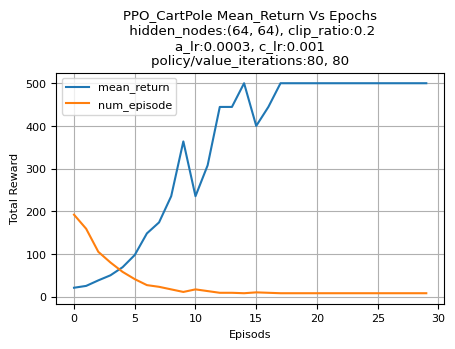

In [10]:
conditions = f'hidden_nodes:{hidden_sizes}, clip_ratio:{clip_ratio}\n\
a_lr:{policy_learning_rate}, c_lr:{value_function_learning_rate}\n\
policy/value_iterations:{train_policy_iterations}, {train_value_iterations}'

plt.title(f"PPO_CartPole Mean_Return Vs Epochs\n {conditions}")
plt.plot(mean_return,label='mean_return')
plt.plot(num_episode_list,label='num_episode')
plt.xlabel("Episods")
plt.ylabel("Total Reward")
#plt.ylim(0,200)
plt.grid(True)
plt.legend()
plt.show()

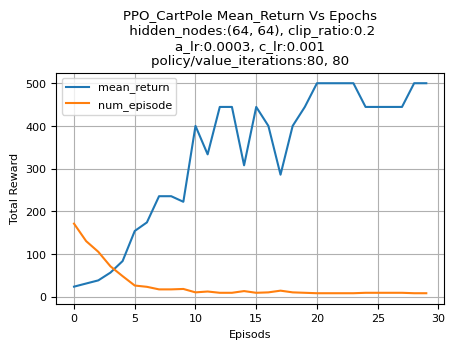

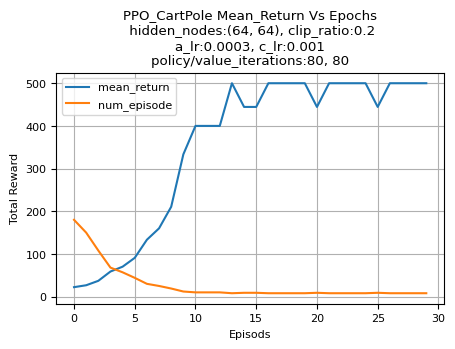

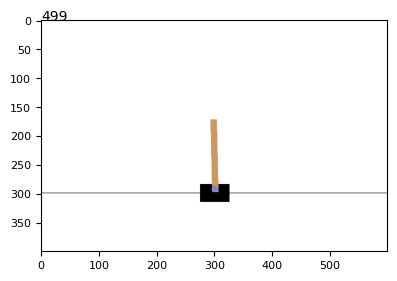

500.0


In [11]:
from IPython.display import clear_output

env = gym.make("CartPole-v1",render_mode="rgb_array")

state,_ = env.reset()
action_l = []
rewards = 0
plt.figure(figsize=(5,3))
for i in range(500): # while True:
    plt.imshow(env.render())
    plt.text(0,0,str(i),fontsize=10)
    state_tensor = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
    logits = actor(state_tensor)
    distribution = Categorical(logits=logits)
    action = distribution.sample()
    state, reward, done , info, _ = env.step(action.item()) # Convert action tensor to integer
    clear_output(wait=True)
    rewards += reward
    if done: break;
    else: plt.show()
print(rewards)
env.close()